# Phase 4: Forecasting Models -- XGBoost vs. LSTM

## The core comparison this notebook is built around

XGBoost gets your Phase 3 hand-engineered feature table (lags, rolling
stats, calendar, temperature). The LSTM gets something deliberately
different: a raw sliding window of the past 168 hours of demand and
temperature, with NO pre-computed lag/rolling features -- it has to
discover daily/weekly structure on its own. Feeding both models identical
inputs would make this a much less interesting comparison; the honest
version tests each model doing what it's actually good at.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)

## 1. Load data and define the feature list SAFELY

The saved CSVs contain every column from the pipeline, not just your final
chosen features -- including raw `market_demand` (nearly a clone of the
target, since Market Demand = Ontario Demand + exports), raw `hoep`
(same-hour price -- not available at forecast time any more than same-hour
demand is), raw `temperature_c` (the real, non-noisy value -- we only want
the forecast-simulated version), and a leftover `year_source` tagging
column from ingestion. An explicit exclusion list, not a blind "everything
except the target," is how we keep leakage out here.

In [7]:
train_df = pd.read_csv('../data/processed/train.csv', parse_dates=['datetime'])
test_2023 = pd.read_csv('../data/processed/test_2023.csv', parse_dates=['datetime'])
test_2024 = pd.read_csv('../data/processed/test_2024.csv', parse_dates=['datetime'])
test_2025 = pd.read_csv('../data/processed/test_2025.csv', parse_dates=['datetime'])

TARGET_COL = 'ontario_demand'
EXCLUDE_COLS = {
    'datetime', TARGET_COL,
    'market_demand',       # near-duplicate of the target -- leakage
    'hoep',                # raw same-hour price -- not available at forecast time
    'temperature_c'        # raw actual temperature -- only the *_forecast version is fair game
}

feature_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]
print(f"Feature count: {len(feature_cols)}")
print(feature_cols)

Feature count: 28
['demand_lag_24h', 'hoep_lag_24h', 'demand_lag_48h', 'hoep_lag_48h', 'demand_lag_72h', 'hoep_lag_72h', 'demand_lag_168h', 'hoep_lag_168h', 'demand_lag_336h', 'hoep_lag_336h', 'demand_rolling_24h_mean', 'demand_rolling_24h_std', 'demand_rolling_48h_mean', 'demand_rolling_72h_mean', 'demand_rolling_168h_mean', 'demand_rolling_168h_std', 'demand_rolling_336h_mean', 'demand_rolling_336h_std', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'is_pandemic_period', 'temperature_c_forecast', 'heating_degree_hours', 'cooling_degree_hours']


## 2. XGBoost

Carving out a validation slice (2022) from training, used ONLY for early
stopping -- so the model stops adding trees once it stops improving on data
it wasn't fit to, a standard defense against overfitting. This is separate
from and never touches the 2023-2025 test sets, which stay untouched until
final evaluation below.

In [10]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_distributions = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
}

tscv = TimeSeriesSplit(n_splits=5)  # 5 sequential, chronological train/val folds

search = RandomizedSearchCV(
    XGBRegressor(n_estimators=500, random_state=42),
    param_distributions=param_distributions,
    n_iter=30,               # 30 random combinations, not exhaustive grid
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
)
search.fit(train_df[feature_cols], train_df[TARGET_COL])
print(search.best_params_)

{'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 1, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [11]:
xgb_fit_df = train_df[train_df['datetime'] < '2022-01-01']
xgb_val_df = train_df[train_df['datetime'] >= '2022-01-01']

xgb_model = XGBRegressor(
    **search.best_params_,
    n_estimators=1000,
    early_stopping_rounds=30,
    random_state=42,
)

xgb_model.fit(
    xgb_fit_df[feature_cols], xgb_fit_df[TARGET_COL],
    eval_set=[(xgb_val_df[feature_cols], xgb_val_df[TARGET_COL])],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration} (of 1000 max)")

Best iteration: 152 (of 1000 max)


## 3. Evaluation function (shared by both models)

MAE in raw MW (easy to sanity-check against typical demand magnitudes) and
MAPE as a percentage (easier to compare across years/models at a glance).

In [12]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:>20}:  MAE = {mae:8.1f} MW   RMSE = {rmse:8.1f} MW   MAPE = {mape:5.2f}%")
    return {'label': label, 'mae': mae, 'rmse': rmse, 'mape': mape}

results = []
for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    preds = xgb_model.predict(test_set[feature_cols])
    results.append(evaluate(test_set[TARGET_COL].values, preds, f'XGBoost {year_label}'))

        XGBoost 2023:  MAE =    488.8 MW   RMSE =    636.4 MW   MAPE =  3.09%
        XGBoost 2024:  MAE =    535.9 MW   RMSE =    710.5 MW   MAPE =  3.30%
XGBoost 2025 (partial):  MAE =    511.0 MW   RMSE =    653.1 MW   MAPE =  3.05%


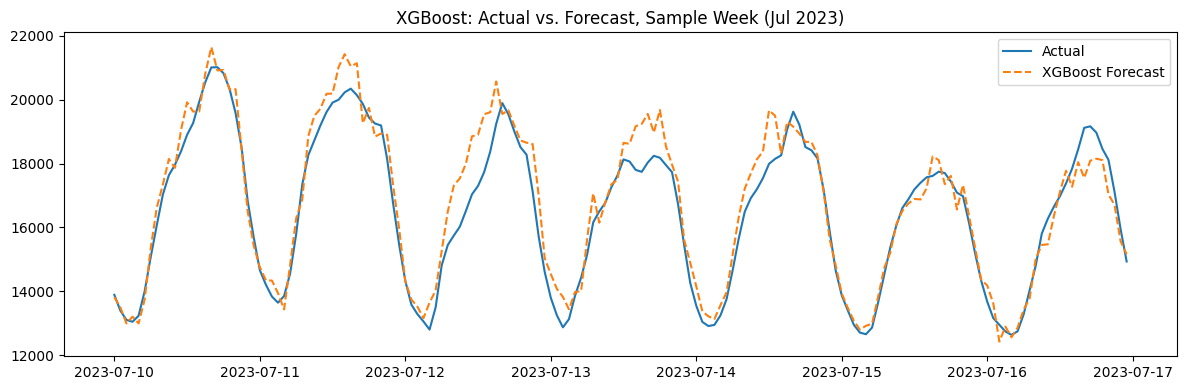

In [13]:
# Visual check: one sample week from 2023, forecast vs actual
sample_week = test_2023[(test_2023['datetime'] >= '2023-07-10') & (test_2023['datetime'] < '2023-07-17')]
sample_preds = xgb_model.predict(sample_week[feature_cols])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample_week['datetime'], sample_week[TARGET_COL], label='Actual')
ax.plot(sample_week['datetime'], sample_preds, label='XGBoost Forecast', linestyle='--')
plt.title('XGBoost: Actual vs. Forecast, Sample Week (Jul 2023)')
plt.legend()
plt.tight_layout()
plt.show()

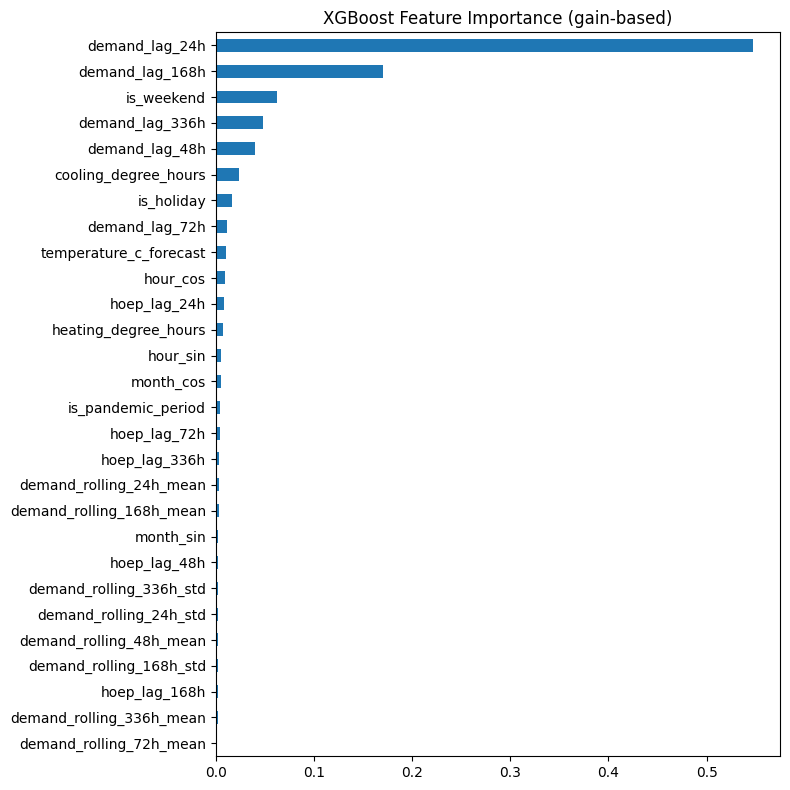

In [14]:
# Feature importance from the final trained model
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
plt.title('XGBoost Feature Importance (gain-based)')
plt.tight_layout()
plt.show()

## 4. The LSTM -- raw sequences, not engineered features

Building sliding windows of the past 168 raw hours of demand and
temperature (forecast-simulated), predicting demand 24 hours ahead -- the
same leakage-safe cutoff discipline as Phase 3, just with a sequence input
instead of hand-crafted lag/rolling summaries.

Requires `tensorflow` (see the Mac-specific `tensorflow-macos`/
`tensorflow-metal` note from Phase 0 setup).

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# Confirm the M1 GPU is actually being used via Metal, not silently
# falling back to CPU-only. Should list a 'GPU' device alongside 'CPU'.
print(f"TensorFlow version: {tf.__version__}")
print(f"Devices available: {tf.config.list_physical_devices()}")

In [ ]:
full_df = pd.read_csv('../data/processed/model_ready_dataset.csv', parse_dates=['datetime'])
full_df = full_df.sort_values('datetime').reset_index(drop=True)

SEQ_COLS = ['ontario_demand', 'temperature_c_forecast']
WINDOW = 168   # trailing hours of raw history
HORIZON = 24   # predict this many hours ahead of the END of the window


def build_sequences(frame: pd.DataFrame, target_start: pd.Timestamp, target_end: pd.Timestamp):
    """
    Builds (X, y, datetimes) for every target timestamp in
    [target_start, target_end), using the WINDOW raw hours ending
    HORIZON hours before each target -- i.e. exactly the data that would
    genuinely be available at forecast time. Sequence inputs are allowed
    to reach into data before target_start (real past history); only the
    TARGET must fall inside the requested range.
    """
    values = frame[SEQ_COLS].values
    timestamps = frame['datetime'].values

    X, y, dt_out = [], [], []
    target_mask = (frame['datetime'] >= target_start) & (frame['datetime'] < target_end)
    target_indices = np.where(target_mask)[0]

    for idx in target_indices:
        window_end = idx - HORIZON        # last index INCLUDED in the input window
        window_start = window_end - WINDOW + 1
        if window_start < 0:
            continue  # not enough history yet (only affects the very start of 2002)
        X.append(values[window_start:window_end + 1])
        y.append(values[idx, 0])          # ontario_demand at the target index
        dt_out.append(timestamps[idx])

    return np.array(X), np.array(y), np.array(dt_out)


X_fit, y_fit, _ = build_sequences(full_df, pd.Timestamp('2002-01-01'), pd.Timestamp('2022-01-01'))
X_val, y_val, _ = build_sequences(full_df, pd.Timestamp('2022-01-01'), pd.Timestamp('2023-01-01'))
X_test_2023, y_test_2023, dt_2023 = build_sequences(full_df, pd.Timestamp('2023-01-01'), pd.Timestamp('2024-01-01'))
X_test_2024, y_test_2024, dt_2024 = build_sequences(full_df, pd.Timestamp('2024-01-01'), pd.Timestamp('2025-01-01'))
X_test_2025, y_test_2025, dt_2025 = build_sequences(full_df, pd.Timestamp('2025-01-01'), pd.Timestamp('2025-05-01'))

print(f"Fit sequences:  {X_fit.shape}")
print(f"Val sequences:  {X_val.shape}")
print(f"Test 2023:      {X_test_2023.shape}")

NotFoundError: dlopen(/Users/jamesgough/Documents/ontario-grid-brain/.venv/lib/python3.10/site-packages/tensorflow-plugins/libmetal_plugin.dylib, 0x0006): Library not loaded: @rpath/_pywrap_tensorflow_internal.so
  Referenced from: <8B62586B-B082-3113-93AB-FD766A9960AE> /Users/jamesgough/Documents/ontario-grid-brain/.venv/lib/python3.10/site-packages/tensorflow-plugins/libmetal_plugin.dylib
  Reason: tried: '/Users/jamesgough/Documents/ontario-grid-brain/.venv/lib/python3.10/site-packages/tensorflow-plugins/../_solib_darwin_arm64/_U@local_Uconfig_Utf_S_S_C_Upywrap_Utensorflow_Uinternal___Uexternal_Slocal_Uconfig_Utf/_pywrap_tensorflow_internal.so' (no such file), '/Users/jamesgough/Documents/ontario-grid-brain/.venv/lib/python3.10/site-packages/tensorflow-plugins/../_solib_darwin_arm64/_U@local_Uconfig_Utf_S_S_C_Upywrap_Utensorflow_Uinternal___Uexternal_Slocal_Uconfig_Utf/_pywrap_tensorflow_internal.so' (no such file), '/Users/jamesgough/miniforge3/bin/../lib/_pywrap_tensorflow_interna

### Scaling -- same fit-on-train-only discipline as Phase 3

A separate scaler from XGBoost's, since this is scaling raw sequence
values (demand in MW, temperature in °C), not the engineered feature
table. Fit on the flattened FIT sequences only, then applied everywhere
else.

In [ ]:
n_features = len(SEQ_COLS)
seq_scaler = StandardScaler()
seq_scaler.fit(X_fit.reshape(-1, n_features))

def scale_sequences(X):
    shape = X.shape
    return seq_scaler.transform(X.reshape(-1, n_features)).reshape(shape)

X_fit_s = scale_sequences(X_fit)
X_val_s = scale_sequences(X_val)
X_test_2023_s = scale_sequences(X_test_2023)
X_test_2024_s = scale_sequences(X_test_2024)
X_test_2025_s = scale_sequences(X_test_2025)

### Building and training the LSTM

A simple architecture on purpose: one LSTM layer summarizing the 168-hour
window, a small Dense layer, then a single output neuron predicting
demand. `EarlyStopping` plays the same role early stopping did for
XGBoost -- stop once validation loss stops improving, using the same 2022
validation period, never touching the real test years.

In [ ]:
lstm_model = keras.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_fit_s, y_fit,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1,
)

In [ ]:
fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Train loss')
ax.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluate the LSTM, using the exact same metric function as XGBoost

In [ ]:
for year_label, X_s, y_true in [
    ('2023', X_test_2023_s, y_test_2023),
    ('2024', X_test_2024_s, y_test_2024),
    ('2025 (partial)', X_test_2025_s, y_test_2025),
]:
    preds = lstm_model.predict(X_s, verbose=0).flatten()
    results.append(evaluate(y_true, preds, f'LSTM {year_label}'))

## 6. Head-to-head comparison

In [ ]:
results_df = pd.DataFrame(results)
results_df[['model', 'year']] = results_df['label'].str.rsplit(' ', n=1, expand=True)
pivot = results_df.pivot(index='year', columns='model', values='mape')
print(pivot)

pivot.plot(kind='bar', figsize=(8, 5))
plt.title('MAPE by Year: XGBoost vs. LSTM')
plt.ylabel('MAPE (%)')
plt.tight_layout()
plt.show()

## Summary

Whichever model wins, the interesting finding is WHY: XGBoost gets
explicit, hand-engineered temporal structure handed to it directly; the
LSTM has to discover daily/weekly patterns on its own from 168 raw hours.
If they land close together, that's a legitimate, defensible finding in
itself -- it suggests the hand-engineered features captured most of what
matters, and the LSTM's automatic pattern discovery didn't find much
beyond that. Write up whichever result you actually get, including if
XGBoost wins comfortably -- that's a real, explainable outcome, not a
failure of the LSTM.

Next: **Phase 5**, classifying hours into demand risk regimes.